In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
from math import ceil

In [2]:
columns = 8
def show_many(images):
    plt.figure(figsize=(20,10))

    for i, image in enumerate(warped_markers):
        RGB_im = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(ceil(len(warped_markers) / columns + 1), columns, i + 1)
        plt.imshow(RGB_im)
        plt.xticks([]), plt.yticks([])

In [3]:
def show(image):
    RGB_im = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
    plt.imshow(RGB_im)

In [4]:
file = "t4.png"

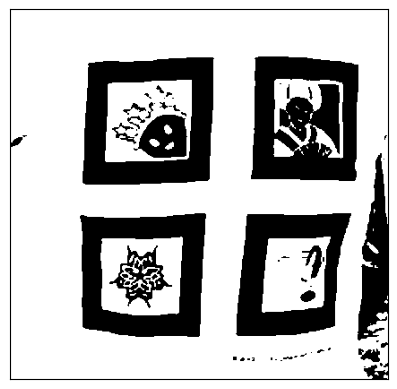

In [5]:
# ========== Etapa 2: Carregar imagem estática ==========
image = cv2.imread(file)  # Substitua pelo nome real da imagem
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
show(binary)

In [6]:
# ========== Etapa 3: Encontrar quadrados ==========
contours, hierarchies = cv2.findContours(binary, cv2.RETR_TREE , cv2.CHAIN_APPROX_SIMPLE)
#contours
#image = cv2.imread(file)
#cv2.drawContours(image, contours, -1, (255, 200, 100), 3)
#show(image)

In [7]:
def order_points(pts):
    # Ordena os pontos no sentido horário: top-left, top-right, bottom-right, bottom-left
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

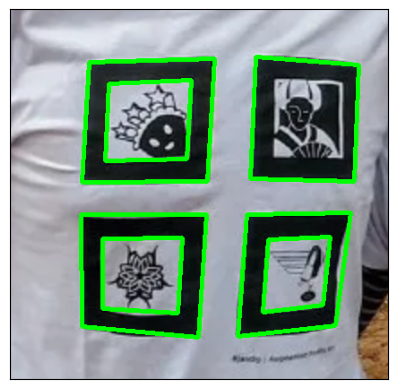

In [19]:
image = cv2.imread(file)
markers = {}
warped_markers = []
for i, cnt in enumerate(contours):
    # Desenha todos os contornos inicialmente em azul claro
    #cv2.drawContours(image, [cnt], -1, (255, 200, 100), 2)

    epsilon = 0.015 * cv2.arcLength(cnt, True)
    min_area = 100
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    if len(approx) == 4 and cv2.isContourConvex(approx):
        # Ignore all small/micro squares
        area = cv2.contourArea(cnt)
        if area <= min_area:
            continue
        # Desenha os contornos com 4 lados em verde (possível marcador)
        cv2.polylines(image, [approx], True, (0, 255, 0), 3)
        square = approx.reshape(4, 2).astype(np.float32)
        dst_pts = np.array([[0, 0], [64, 0], [64, 64], [0, 64]], dtype=np.float32)

        M = cv2.getPerspectiveTransform(order_points(square), dst_pts)
        warped = cv2.warpPerspective(gray, M, (64, 64))
        #show(warped)
        markers[i] = {
            "marker": warped,
            "hierarchy":hierarchies[0][i]
        }
        #score = match_with_patt(warped, patt)

        #if score > 0.7:
        #    # Desenha marcador reconhecido com contorno mais grosso e texto
        #    cv2.polylines(image, [approx], True, (0, 255, 0), 3)
         #   cv2.putText(image, f"Match ({score:.2f})", tuple(approx[0][0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        
# ========== Etapa 5: Mostrar imagem ==========
show(image)

In [9]:
len(markers)

7

[30, 31, 39, 40, 57, 58, 89]
{np.int32(57), np.int32(10), np.int32(30), np.int32(39)}


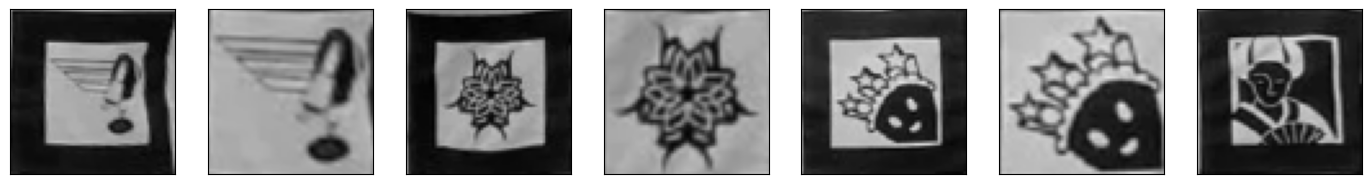

In [10]:
warped_markers = [value["marker"] for key, value in markers.items()]
filtered_hierarchies = [value["hierarchy"] for key, value in markers.items()]
warped_markers_ids = [key for key, value in markers.items()]
parents = set(value["hierarchy"][3] for key,value in markers.items())
print(warped_markers_ids)
print(parents)
show_many(warped_markers)

In [11]:
for i, h in enumerate(filtered_hierarchies):
    print(f"marker: {warped_markers_ids[i]} child: {h[2]} parent: {h[3]}")

marker: 30 child: 31 parent: 10
marker: 31 child: 32 parent: 30
marker: 39 child: 40 parent: 10
marker: 40 child: 41 parent: 39
marker: 57 child: 58 parent: 10
marker: 58 child: 59 parent: 57
marker: 89 child: 90 parent: 10


In [12]:
for k in parents:
    markers.pop(k, None)

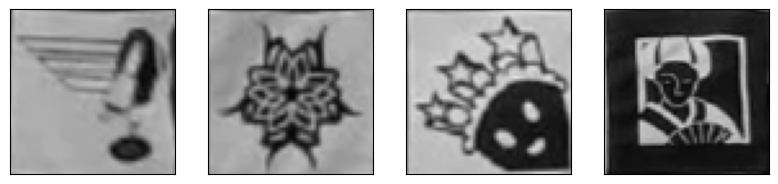

In [13]:
warped_markers = [value["marker"] for key, value in markers.items()]
show_many(warped_markers)